# 🛒 Olist E-Commerce Analytics

## 📌 Project Overview

This project analyzes the Olist Brazilian E-Commerce dataset to uncover insights into sales performance, customer behavior, payment methods, product categories, delivery performance, and customer satisfaction.

The analysis was performed using Python, Pandas, NumPy, Matplotlib, and Seaborn.

## 🎯 Project Objectives

- Analyze overall sales and order performance
- Identify monthly revenue and order trends
- Analyze payment methods and payment revenue
- Identify top-performing product categories
- Analyze customer cities and seller performance
- Understand order status distribution
- Evaluate delivery performance
- Analyze the relationship between delivery time and customer review scores
- Calculate important e-commerce KPIs such as Revenue, Orders, and Average Order Value
- Generate actionable business insights

## 🛠️ Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

## 📂 Dataset

The analysis uses multiple relational datasets from the Olist Brazilian E-Commerce dataset, including:

- Customers
- Orders
- Order Items
- Payments
- Reviews
- Products
- Sellers
- Geolocation
- Product Category Translation

The datasets were analyzed separately and merged where required to avoid unnecessary duplication and maintain data accuracy.

## 1️⃣ Data Loading & Initial Exploration

The Olist dataset consists of multiple CSV files representing different aspects of the e-commerce business.

The datasets were loaded into Pandas DataFrames and inspected for:

- Number of rows and columns
- Column names and data types
- Missing values
- Duplicate records
- Basic statistical information

In [192]:
# Display dataset dimensions

datasets = {
    'Orders': orders,
    'Customers': customers,
    'Payments': payments,
    'Reviews': reviews,
    'Order Items': order_items,
    'Products': products,
    'Category Translation': category_translation
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]:,} rows × {df.shape[1]} columns")

Orders: 99,441 rows × 14 columns
Customers: 99,441 rows × 5 columns
Payments: 103,886 rows × 5 columns
Reviews: 99,224 rows × 7 columns
Order Items: 112,650 rows × 7 columns
Products: 32,951 rows × 9 columns
Category Translation: 71 rows × 2 columns


### Data Quality Checks

The datasets were checked for missing values and duplicate records before performing the analysis.

In [193]:
# Missing values and duplicate records

for name, df in datasets.items():
    print(f"\n{name}")
    print(f"Duplicate rows: {df.duplicated().sum():,}")
    print(f"Missing values: {df.isna().sum().sum():,}")


Orders
Duplicate rows: 0
Missing values: 7,879

Customers
Duplicate rows: 0
Missing values: 0

Payments
Duplicate rows: 0
Missing values: 0

Reviews
Duplicate rows: 0
Missing values: 145,903

Order Items
Duplicate rows: 0
Missing values: 0

Products
Duplicate rows: 0
Missing values: 2,448

Category Translation
Duplicate rows: 0
Missing values: 0


In [21]:
# Convert date columns to datetime

date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

print("Date columns converted successfully.")

Date columns converted successfully.


In [22]:
# Create useful date features

orders['purchase_year'] = orders['order_purchase_timestamp'].dt.year
orders['purchase_month'] = orders['order_purchase_timestamp'].dt.month
orders['purchase_month_name'] = orders['order_purchase_timestamp'].dt.month_name()
orders['purchase_day'] = orders['order_purchase_timestamp'].dt.day
orders['purchase_weekday'] = orders['order_purchase_timestamp'].dt.day_name()

orders[['order_purchase_timestamp',
        'purchase_year',
        'purchase_month',
        'purchase_month_name',
        'purchase_weekday']].head()

,order_purchase_timestamp,purchase_year,purchase_month,purchase_month_name,purchase_weekday
0,2017-10-02 10:56:33,2017,10,October,Monday
1,2018-07-24 20:41:37,2018,7,July,Tuesday
2,2018-08-08 08:38:49,2018,8,August,Wednesday
3,2017-11-18 19:28:06,2017,11,November,Saturday
4,2018-02-13 21:18:39,2018,2,February,Tuesday


In [23]:
# Calculate delivery days for delivered orders

orders['delivery_days'] = np.where(
    orders['order_status'] == 'delivered',
    (
        orders['order_delivered_customer_date']
        - orders['order_purchase_timestamp']
    ).dt.total_seconds() / (24 * 60 * 60),
    np.nan
)

print("Delivery days calculated successfully.")
print(f"Average delivery time: {orders['delivery_days'].mean():.2f} days")

Delivery days calculated successfully.
Average delivery time: 12.56 days


In [24]:
!pip install pandas numpy matplotlib seaborn openpyxl


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl

print("All libraries imported successfully!")

All libraries imported successfully!


In [26]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\user\Projects
['.ipynb_checkpoints', 'Ecommerce.ipynb']


In [27]:
import os

dataset_path = r"C:\Users\user\OneDrive\Desktop\Ecommerce Analytics\Olist-Ecommerce-Analytics\Datasets"

print("Dataset files:")
for file in os.listdir(dataset_path):
    print(file)

Dataset files:
olist_customers_dataset.csv
olist_geolocation_dataset.csv
Olist_Merge.xlsx
olist_orders_dataset.csv
olist_order_items_dataset.csv
olist_order_payments_dataset.csv
olist_order_reviews_dataset.csv
olist_products_dataset.csv
olist_sellers_dataset.csv
product_category_name_translation.csv


In [28]:
import pandas as pd

In [29]:
orders = pd.read_csv(dataset_path + r"\olist_orders_dataset.csv")

print("Orders dataset loaded successfully!")
print("Rows:", orders.shape[0])
print("Columns:", orders.shape[1])

Orders dataset loaded successfully!
Rows: 99441
Columns: 8


In [30]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [31]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [32]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [33]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [34]:
orders.duplicated().sum()

np.int64(0)

## 2️⃣ Data Cleaning & Transformation

The datasets were cleaned and transformed to prepare them for analysis.

### Key Data Preparation Steps

- Converted date columns to datetime format
- Created year, month, day, and weekday features
- Calculated delivery days for delivered orders
- Aggregated payment records at the order level
- Merged related datasets where required
- Translated product category names into English
- Checked for missing values and duplicate records
- Created analysis-ready datasets for business analysis

In [35]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

print("Date columns converted successfully!")

Date columns converted successfully!


In [36]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [37]:
# Create date-based analytical columns

orders['purchase_year'] = orders['order_purchase_timestamp'].dt.year
orders['purchase_month'] = orders['order_purchase_timestamp'].dt.month
orders['purchase_month_name'] = orders['order_purchase_timestamp'].dt.month_name()
orders['purchase_day'] = orders['order_purchase_timestamp'].dt.day
orders['purchase_weekday'] = orders['order_purchase_timestamp'].dt.day_name()

print("Date analysis columns created successfully!")

Date analysis columns created successfully!


In [38]:
orders[
    [
        'order_purchase_timestamp',
        'purchase_year',
        'purchase_month',
        'purchase_month_name',
        'purchase_day',
        'purchase_weekday'
    ]
].head()

,order_purchase_timestamp,purchase_year,purchase_month,purchase_month_name,purchase_day,purchase_weekday
0,2017-10-02 10:56:33,2017,10,October,2,Monday
1,2018-07-24 20:41:37,2018,7,July,24,Tuesday
2,2018-08-08 08:38:49,2018,8,August,8,Wednesday
3,2017-11-18 19:28:06,2017,11,November,18,Saturday
4,2018-02-13 21:18:39,2018,2,February,13,Tuesday


In [39]:
import numpy as np

In [40]:
orders['delivery_days'] = np.where(
    orders['order_status'] == 'delivered',
    (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.total_seconds() / (24 * 60 * 60),
    np.nan
)

print("Delivery days calculated successfully!")

Delivery days calculated successfully!


In [41]:
orders[['order_status', 'order_purchase_timestamp',
        'order_delivered_customer_date', 'delivery_days']].head(10)

,order_status,order_purchase_timestamp,order_delivered_customer_date,delivery_days
0,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,8.436574
1,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,13.782037
2,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,9.394213
3,delivered,2017-11-18 19:28:06,2017-12-02 00:28:42,13.208750
4,delivered,2018-02-13 21:18:39,2018-02-16 18:17:02,2.873877
5,delivered,2017-07-09 21:57:05,2017-07-26 10:57:55,16.542245
6,invoiced,2017-04-11 12:22:08,NaT,NaN
7,delivered,2017-05-16 13:10:30,2017-05-26 12:55:51,9.989826
8,delivered,2017-01-23 18:29:09,2017-02-02 14:08:10,9.818762
9,delivered,2017-07-29 11:55:02,2017-08-16 17:14:30,18.221852


In [42]:
print("Minimum delivery days:", orders['delivery_days'].min())
print("Maximum delivery days:", orders['delivery_days'].max())
print("Average delivery days:", orders['delivery_days'].mean())

Minimum delivery days: 0.5334143518518518
Maximum delivery days: 209.6286111111111
Average delivery days: 12.558217098051976


In [43]:
orders['delivery_days'].describe()

count    96470.000000
mean        12.558217
std          9.546156
min          0.533414
25%          6.766204
50%         10.217477
75%         15.720182
max        209.628611
Name: delivery_days, dtype: float64

In [44]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [45]:
orders['order_status'].value_counts(normalize=True).mul(100).round(2)

order_status
delivered      97.02
shipped         1.11
canceled        0.63
unavailable     0.61
invoiced        0.32
processing      0.30
created         0.01
approved        0.00
Name: proportion, dtype: float64

In [46]:
payments = pd.read_csv(
    dataset_path + r"\olist_order_payments_dataset.csv"
)

print("Payments dataset loaded successfully!")
print("Rows:", payments.shape[0])
print("Columns:", payments.shape[1])

Payments dataset loaded successfully!
Rows: 103886
Columns: 5


In [47]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [48]:
payments.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')

In [49]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [50]:
payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [51]:
payments.duplicated().sum()

np.int64(0)

In [52]:
payments['payment_type'].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [53]:
payments[['payment_value', 'payment_installments']].describe()

,payment_value,payment_installments
count,103886.000000,103886.000000
mean,154.100380,2.853349
std,217.494064,2.687051
min,0.000000,0.000000
25%,56.790000,1.000000
50%,100.000000,1.000000
75%,171.837500,4.000000
max,13664.080000,24.000000


In [54]:
payments[['payment_value', 'payment_installments']].head(10)

,payment_value,payment_installments
0,99.33,8
1,24.39,1
2,65.71,1
3,107.78,8
4,128.45,2
5,96.12,2
6,81.16,1
7,51.84,3
8,341.09,6
9,51.95,1


In [55]:
print("Total payment records:", len(payments))
print("Unique orders in payments:", payments['order_id'].nunique())

Total payment records: 103886
Unique orders in payments: 99440


In [56]:
reviews = pd.read_csv(
    dataset_path + r"\olist_order_reviews_dataset.csv"
)

print("Reviews dataset loaded successfully!")
print("Rows:", reviews.shape[0])
print("Columns:", reviews.shape[1])

Reviews dataset loaded successfully!
Rows: 99224
Columns: 7


In [57]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [58]:
reviews.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [59]:
reviews.isnull().sum()


review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [60]:
reviews.duplicated().sum()

np.int64(0)

In [61]:
reviews['review_score'].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [62]:
reviews['review_score'].value_counts(normalize=True).sort_index().mul(100).round(2)

review_score
1    11.51
2     3.18
3     8.24
4    19.29
5    57.78
Name: proportion, dtype: float64

In [63]:
order_items = pd.read_csv(
    dataset_path + r"\olist_order_items_dataset.csv"
)

print("Order Items dataset loaded successfully!")
print("Rows:", order_items.shape[0])
print("Columns:", order_items.shape[1])

Order Items dataset loaded successfully!
Rows: 112650
Columns: 7


In [64]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [65]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [66]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [67]:
order_items.duplicated().sum()

np.int64(0)

In [68]:
print("Rows:", order_items.shape[0])
print("Columns:", order_items.shape[1])

Rows: 112650
Columns: 7


In [69]:
order_items[['price', 'freight_value']].describe()

,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


In [70]:
products = pd.read_csv(
    dataset_path + r"\olist_products_dataset.csv"
)

print("Products dataset loaded successfully!")
print("Rows:", products.shape[0])
print("Columns:", products.shape[1])

Products dataset loaded successfully!
Rows: 32951
Columns: 9


In [71]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [72]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [73]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [74]:
products.duplicated().sum()

np.int64(0)

In [75]:
category_translation = pd.read_csv(
    dataset_path + r"\product_category_name_translation.csv"
)

print("Category translation dataset loaded successfully!")
print("Rows:", category_translation.shape[0])
print("Columns:", category_translation.shape[1])

Category translation dataset loaded successfully!
Rows: 71
Columns: 2


In [76]:
category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [77]:
category_translation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [78]:
category_translation.isnull().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

In [79]:
category_translation.duplicated().sum()

np.int64(0)

In [80]:
customers = pd.read_csv(
    dataset_path + r"\olist_customers_dataset.csv"
)

print("Customers dataset loaded successfully!")
print("Rows:", customers.shape[0])
print("Columns:", customers.shape[1])

Customers dataset loaded successfully!
Rows: 99441
Columns: 5


In [81]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [82]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [83]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [84]:
customers.duplicated().sum()

np.int64(0)

In [85]:
customers['customer_state'].value_counts().head(10)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

In [86]:
customers[customers['customer_state'] == 'SP'].shape[0]

41746

In [87]:
print("Total customer records:", len(customers))
print("Unique customer IDs:", customers['customer_id'].nunique())
print("Unique customer unique IDs:", customers['customer_unique_id'].nunique())

Total customer records: 99441
Unique customer IDs: 99441
Unique customer unique IDs: 96096


In [88]:
customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')

In [89]:
#Building the Analysis Dataset


In [90]:
orders_customers = orders.merge(
    customers[['customer_id', 'customer_unique_id', 'customer_city', 'customer_state']],
    on='customer_id',
    how='left'
)

print("Orders + Customers merged successfully!")
print("Rows:", orders_customers.shape[0])
print("Columns:", orders_customers.shape[1])

Orders + Customers merged successfully!
Rows: 99441
Columns: 17


In [91]:
orders_customers.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,purchase_month_name,purchase_day,purchase_weekday,delivery_days,customer_unique_id,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,October,2,Monday,8.436574,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,July,24,Tuesday,13.782037,af07308b275d755c9edb36a90c618231,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,August,8,Wednesday,9.394213,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,November,18,Saturday,13.208750,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,February,13,Tuesday,2.873877,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP


In [92]:
print("Original Orders rows:", len(orders))
print("Merged rows:", len(orders_customers))

Original Orders rows: 99441
Merged rows: 99441


In [93]:
payments_by_order = payments.groupby('order_id').agg(
    total_payment=('payment_value', 'sum'),
    payment_installments=('payment_installments', 'max'),
    payment_types=('payment_type', lambda x: ', '.join(x.unique()))
).reset_index()

print("Payments aggregated successfully!")
print("Rows:", payments_by_order.shape[0])
print("Columns:", payments_by_order.shape[1])

Payments aggregated successfully!
Rows: 99440
Columns: 4


In [94]:
payments_by_order.head()

,order_id,total_payment,payment_installments,payment_types
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,credit_card


In [95]:
print("Unique payment orders:", payments_by_order['order_id'].nunique())
print("Duplicate order IDs:", payments_by_order['order_id'].duplicated().sum())

Unique payment orders: 99440
Duplicate order IDs: 0


In [96]:
orders_customers_payments = orders_customers.merge(
    payments_by_order,
    on='order_id',
    how='left'
)

print("Orders + Customers + Payments merged successfully!")
print("Rows:", orders_customers_payments.shape[0])
print("Columns:", orders_customers_payments.shape[1])

Orders + Customers + Payments merged successfully!
Rows: 99441
Columns: 20


In [97]:
print("Original Orders:", len(orders))
print("Final merged rows:", len(orders_customers_payments))

Original Orders: 99441
Final merged rows: 99441


In [98]:
orders_customers_payments['total_payment'].isnull().sum()

np.int64(1)

In [99]:
reviews_by_order = reviews.groupby('order_id').agg(
    review_score=('review_score', 'mean')
).reset_index()

print("Reviews aggregated successfully!")
print("Rows:", reviews_by_order.shape[0])
print("Unique orders:", reviews_by_order['order_id'].nunique())

Reviews aggregated successfully!
Rows: 98673
Unique orders: 98673


In [100]:
print("Duplicate order IDs:",
      reviews_by_order['order_id'].duplicated().sum())

Duplicate order IDs: 0


In [101]:
orders_analysis = orders_customers_payments.merge(
    reviews_by_order,
    on='order_id',
    how='left'
)

print("Reviews merged successfully!")
print("Rows:", orders_analysis.shape[0])
print("Columns:", orders_analysis.shape[1])

Reviews merged successfully!
Rows: 99441
Columns: 21


In [102]:
print("Original Orders:", len(orders))
print("Analysis Dataset:", len(orders_analysis))

Original Orders: 99441
Analysis Dataset: 99441


In [103]:
orders_analysis.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,...,purchase_day,purchase_weekday,delivery_days,customer_unique_id,customer_city,customer_state,total_payment,payment_installments,payment_types,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,...,2,Monday,8.436574,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,38.71,1.0,"credit_card, voucher",4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,...,24,Tuesday,13.782037,af07308b275d755c9edb36a90c618231,barreiras,BA,141.46,1.0,boleto,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,...,8,Wednesday,9.394213,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,179.12,3.0,credit_card,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,...,18,Saturday,13.208750,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,72.20,1.0,credit_card,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,...,13,Tuesday,2.873877,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,28.62,1.0,credit_card,5.0


In [104]:
order_items_products = order_items.merge(
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

print("Order Items + Products merged successfully!")
print("Rows:", order_items_products.shape[0])
print("Columns:", order_items_products.shape[1])

Order Items + Products merged successfully!
Rows: 112650
Columns: 8


In [105]:
print("Original Order Items:", len(order_items))
print("Merged rows:", len(order_items_products))

Original Order Items: 112650
Merged rows: 112650


In [106]:
sales_analysis = order_items_products.merge(
    category_translation,
    on='product_category_name',
    how='left'
)

print("Category translation merged successfully!")
print("Rows:", sales_analysis.shape[0])
print("Columns:", sales_analysis.shape[1])

Category translation merged successfully!
Rows: 112650
Columns: 9


In [107]:
sales_analysis.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,garden_tools


In [108]:
sales_analysis['item_revenue'] = sales_analysis['price']

In [109]:
sales_analysis[['price', 'freight_value', 'item_revenue']].head(10)

,price,freight_value,item_revenue
0,58.90,13.29,58.90
1,239.90,19.93,239.90
2,199.00,17.87,199.00
3,12.99,12.79,12.99
4,199.90,18.14,199.90
5,21.90,12.69,21.90
6,19.90,11.85,19.90
7,810.00,70.75,810.00
8,145.95,11.65,145.95
9,53.99,11.40,53.99


In [110]:
top_categories = (
    sales_analysis
    .groupby('product_category_name_english', dropna=False)['item_revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_categories

product_category_name_english
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
furniture_decor           729762.49
cool_stuff                635290.85
housewares                632248.66
auto                      592720.11
garden_tools              485256.46
Name: item_revenue, dtype: float64

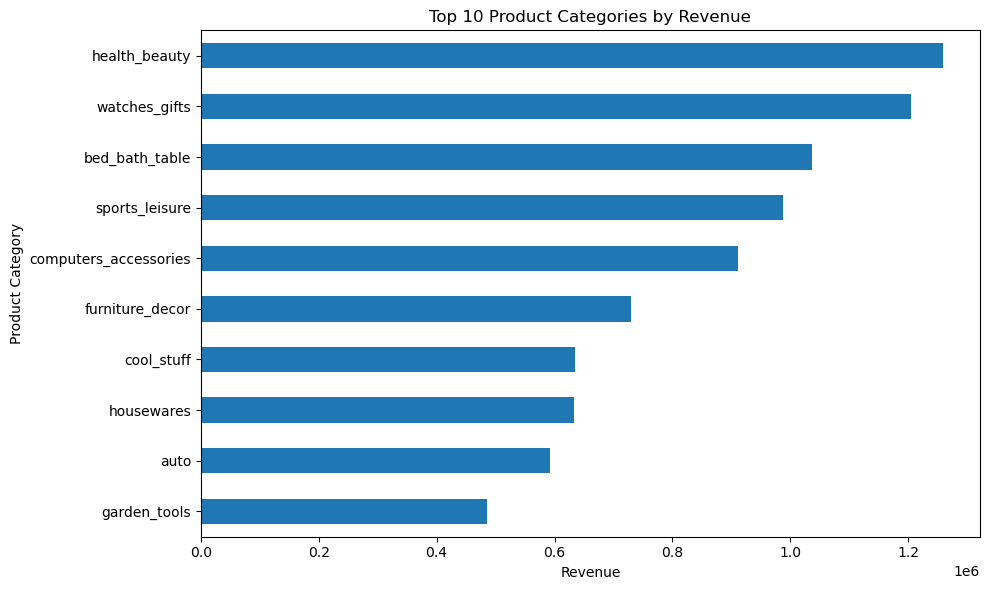

In [111]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

top_categories.sort_values().plot(
    kind='barh'
)

plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

In [112]:
monthly_orders = (
    orders_analysis
    .groupby(['purchase_year', 'purchase_month', 'purchase_month_name'])
    .size()
    .reset_index(name='total_orders')
)

monthly_orders = monthly_orders.sort_values(
    ['purchase_year', 'purchase_month']
)

monthly_orders.head(15)

,purchase_year,purchase_month,purchase_month_name,total_orders
0,2016,9,September,4
1,2016,10,October,324
2,2016,12,December,1
3,2017,1,January,800
4,2017,2,February,1780
5,2017,3,March,2682
6,2017,4,April,2404
7,2017,5,May,3700
8,2017,6,June,3245
9,2017,7,July,4026


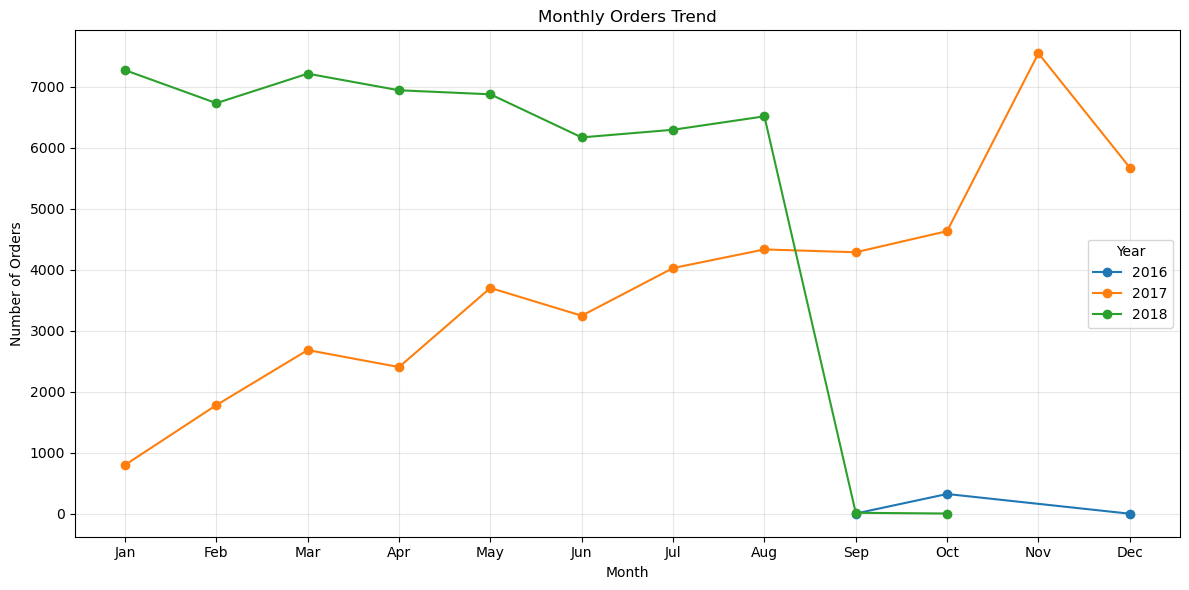

In [113]:
plt.figure(figsize=(12, 6))

month_names = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]

for year in sorted(monthly_orders['purchase_year'].unique()):
    year_data = monthly_orders[
        monthly_orders['purchase_year'] == year
    ].sort_values('purchase_month')

    plt.plot(
        year_data['purchase_month'],
        year_data['total_orders'],
        marker='o',
        label=str(year)
    )

plt.title('Monthly Orders Trend')
plt.xlabel('Month')
plt.ylabel('Number of Orders')

plt.xticks(
    range(1, 13),
    month_names
)

plt.legend(title='Year')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [114]:
payment_type_orders = (
    payments.groupby('payment_type')['order_id']
    .nunique()
    .sort_values(ascending=False)
)

payment_type_orders

payment_type
credit_card    76505
boleto         19784
voucher         3866
debit_card      1528
not_defined        3
Name: order_id, dtype: int64

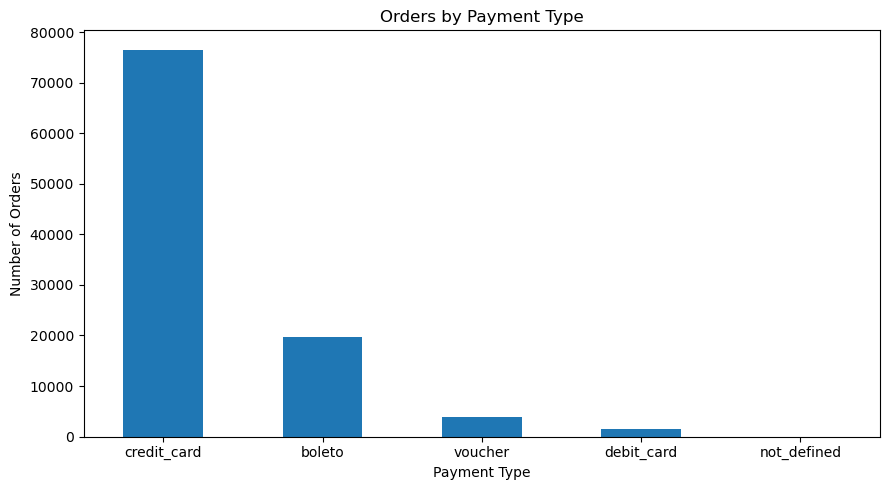

In [115]:
plt.figure(figsize=(9, 5))

payment_type_orders.plot(
    kind='bar'
)

plt.title('Orders by Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [116]:
#5-Star Credit Card Orders


In [117]:
five_star_credit_card_orders = orders_analysis[
    (orders_analysis['review_score'] == 5) &
    (orders_analysis['payment_types'].str.contains('credit_card', na=False))
]['order_id'].nunique()

print("5-Star Credit Card Orders:", five_star_credit_card_orders)

5-Star Credit Card Orders: 43890


In [118]:
#Average Delivery Days by Review Score

In [119]:
avg_delivery_by_review = (
    orders_analysis
    .groupby('review_score')['delivery_days']
    .mean()
    .round(2)
)

avg_delivery_by_review

review_score
1.000000    21.34
1.500000    17.53
2.000000    16.66
2.500000    18.67
3.000000    14.24
3.333333    22.03
3.500000    13.28
4.000000    12.31
4.333333     3.77
4.500000    12.80
5.000000    10.68
Name: delivery_days, dtype: float64

In [120]:
# Create a review-level dataset with delivery days
review_delivery = reviews[['order_id', 'review_score']].merge(
    orders[['order_id', 'delivery_days']],
    on='order_id',
    how='left'
)

print("Review + Delivery dataset created!")
print("Rows:", len(review_delivery))

Review + Delivery dataset created!
Rows: 99224


In [121]:
avg_delivery_by_review = (
    review_delivery
    .groupby('review_score')['delivery_days']
    .mean()
    .round(2)
)

avg_delivery_by_review

review_score
1    21.31
2    16.66
3    14.26
4    12.31
5    10.69
Name: delivery_days, dtype: float64

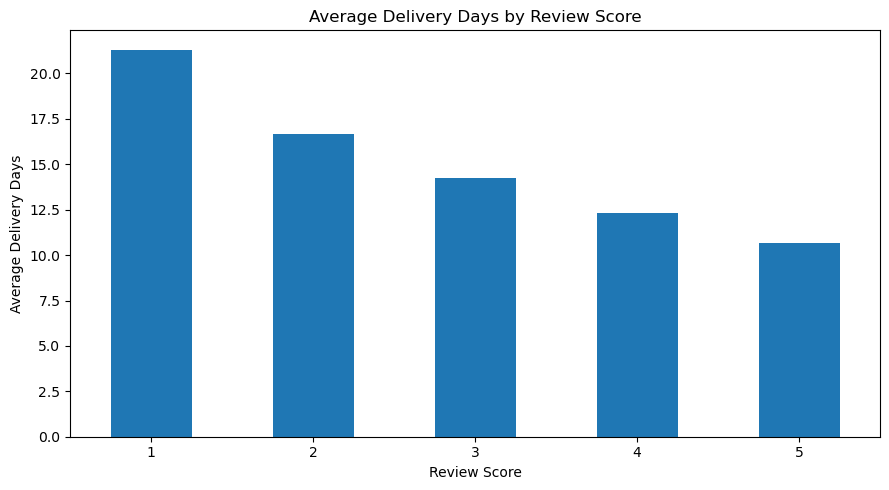

In [122]:
plt.figure(figsize=(9, 5))

avg_delivery_by_review.plot(kind='bar')

plt.title('Average Delivery Days by Review Score')
plt.xlabel('Review Score')
plt.ylabel('Average Delivery Days')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [123]:
#Pet Shop Average Delivery Days

In [124]:
pet_shop_orders = sales_analysis[
    sales_analysis['product_category_name_english'] == 'pet_shop'
]['order_id'].unique()

print("Pet Shop orders:", len(pet_shop_orders))

Pet Shop orders: 1710


In [125]:
pet_shop_delivery = orders[
    orders['order_id'].isin(pet_shop_orders)
]['delivery_days']

print("Average Pet Shop Delivery Days:",
      round(pet_shop_delivery.mean(), 2))

Average Pet Shop Delivery Days: 11.37


In [126]:
pet_shop_summary = pd.DataFrame({
    'Metric': ['Pet Shop Average Delivery Days'],
    'Value': [round(pet_shop_delivery.mean(), 2)]
})

pet_shop_summary

,Metric,Value
0,Pet Shop Average Delivery Days,11.37


In [127]:
#São Paulo Average Price & Payment 

In [128]:
orders_customer = orders.merge(
    customers,
    on='customer_id',
    how='left'
)

print("Orders + Customer dataset created successfully!")
print("Rows:", len(orders_customer))
print("Columns:", len(orders_customer.columns))

Orders + Customer dataset created successfully!
Rows: 99441
Columns: 18


In [129]:
orders_customer[['order_id', 'customer_id', 'customer_city', 'customer_state']].head()

,order_id,customer_id,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,santo andre,SP


In [130]:
sao_paulo_orders = orders_customer[
    orders_customer['customer_city'].str.lower() == 'sao paulo'
][['order_id', 'customer_city']].copy()

print("São Paulo orders:", len(sao_paulo_orders))

São Paulo orders: 15540


In [131]:
sao_paulo_sales = sales_analysis.merge(
    sao_paulo_orders,
    on='order_id',
    how='inner'
)

sao_paulo_avg_price = sao_paulo_sales['price'].mean()

print("São Paulo Average Price:",
      round(sao_paulo_avg_price, 2))

São Paulo Average Price: 107.53


In [132]:
sao_paulo_payment = sao_paulo_orders.merge(
    payments[['order_id', 'payment_value']],
    on='order_id',
    how='inner'
)

print("São Paulo payment records:", len(sao_paulo_payment))

São Paulo payment records: 16221


In [133]:
sao_paulo_avg_payment = sao_paulo_payment['payment_value'].mean()

print("São Paulo Average Payment:",
      round(sao_paulo_avg_payment, 2))

São Paulo Average Payment: 135.83


In [134]:
sao_paulo_summary = pd.DataFrame({
    'Metric': [
        'São Paulo Average Price',
        'São Paulo Average Payment'
    ],
    'Value': [
        round(sao_paulo_avg_price, 2),
        round(sao_paulo_avg_payment, 2)
    ]
})

sao_paulo_summary

,Metric,Value
0,São Paulo Average Price,107.53
1,São Paulo Average Payment,135.83


In [135]:
orders_payment = orders[['order_id', 'order_purchase_timestamp']].merge(
    payments[['order_id', 'payment_value']],
    on='order_id',
    how='inner'
)

orders_payment['day_type'] = np.where(
    orders_payment['order_purchase_timestamp'].dt.dayofweek >= 5,
    'Weekend',
    'Weekday'
)

orders_payment.head()

,order_id,order_purchase_timestamp,payment_value,day_type
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,18.12,Weekday
1,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2.00,Weekday
2,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,18.59,Weekday
3,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,141.46,Weekday
4,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,179.12,Weekday


In [136]:
weekday_weekend_summary = (
    orders_payment
    .groupby('day_type')
    .agg(
        total_payment=('payment_value', 'sum'),
        number_of_orders=('order_id', 'nunique')
    )
    .round(2)
)

weekday_weekend_summary

,total_payment,number_of_orders
day_type,,
Weekday,12367988.08,76593
Weekend,3640884.04,22847


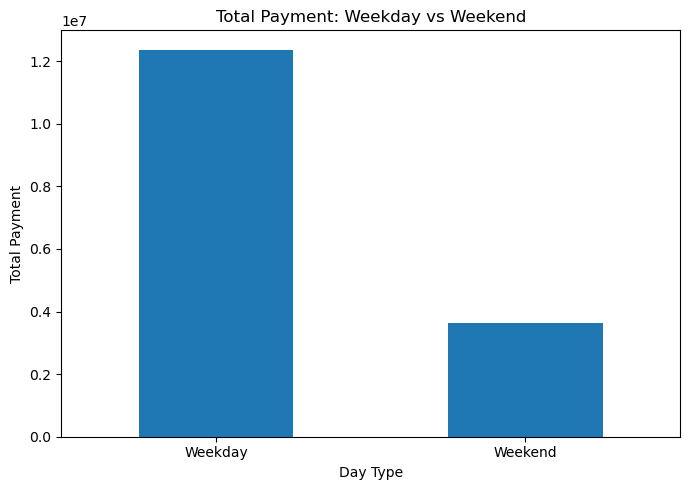

In [137]:
plt.figure(figsize=(7, 5))

weekday_weekend_summary['total_payment'].plot(
    kind='bar'
)

plt.title('Total Payment: Weekday vs Weekend')
plt.xlabel('Day Type')
plt.ylabel('Total Payment')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

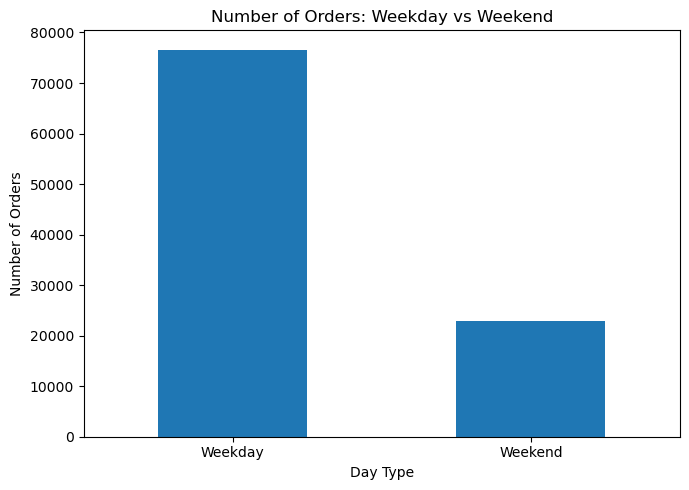

In [138]:
plt.figure(figsize=(7, 5))

weekday_weekend_summary['number_of_orders'].plot(
    kind='bar'
)

plt.title('Number of Orders: Weekday vs Weekend')
plt.xlabel('Day Type')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [139]:
#Order Status Distribution

In [140]:
order_status_summary = (
    orders['order_status']
    .value_counts()
    .to_frame('order_count')
)

order_status_summary['percentage'] = (
    order_status_summary['order_count']
    / order_status_summary['order_count'].sum() * 100
).round(2)

order_status_summary

,order_count,percentage
order_status,,
delivered,96478,97.02
shipped,1107,1.11
canceled,625,0.63
unavailable,609,0.61
invoiced,314,0.32
processing,301,0.30
created,5,0.01
approved,2,0.00


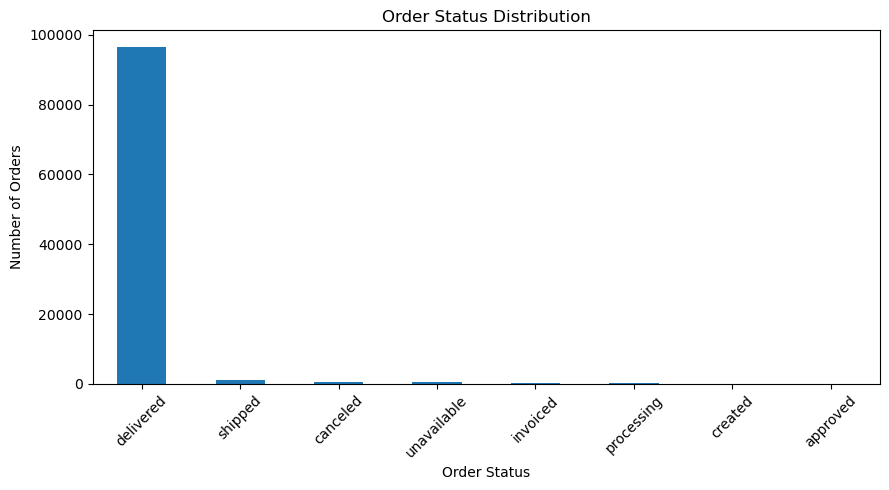

In [141]:
plt.figure(figsize=(9, 5))

order_status_summary['order_count'].plot(
    kind='bar'
)

plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

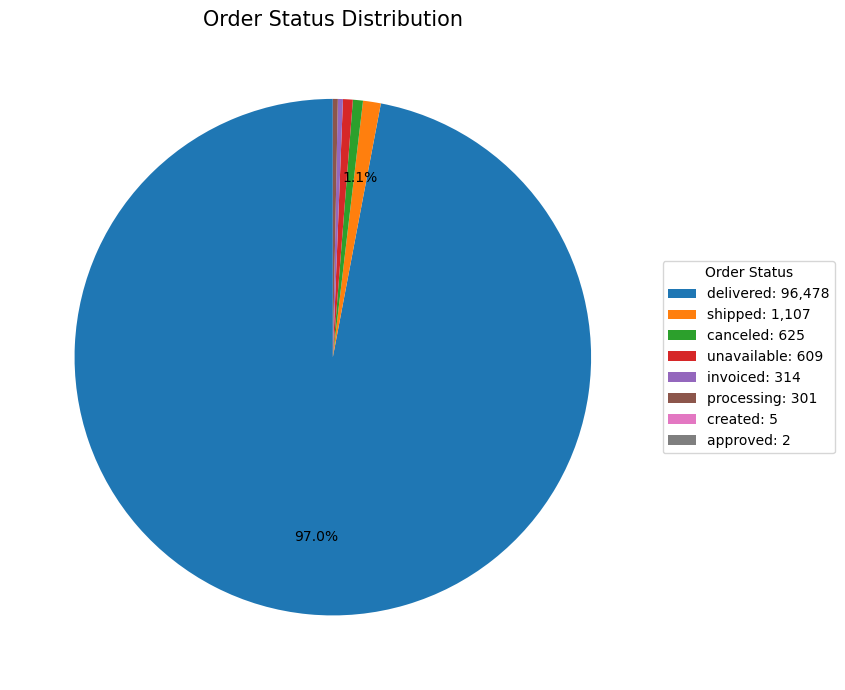

In [142]:
plt.figure(figsize=(9, 7))

data = order_status_summary['order_count']

def autopct_func(pct):
    return f'{pct:.1f}%' if pct >= 1 else ''

wedges, texts, autotexts = plt.pie(
    data,
    autopct=autopct_func,
    startangle=90,
    pctdistance=0.7
)

plt.title('Order Status Distribution', fontsize=15)

plt.legend(
    wedges,
    [f'{status}: {count:,}' for status, count in zip(data.index, data)],
    title='Order Status',
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.show()

In [143]:
#Payment Method Analysis

In [144]:
payment_method_summary = (
    payments.groupby('payment_type')['order_id']
    .nunique()
    .sort_values(ascending=False)
    .to_frame('order_count')
)

payment_method_summary['percentage'] = (
    payment_method_summary['order_count']
    / payment_method_summary['order_count'].sum() * 100
).round(2)

payment_method_summary

,order_count,percentage
payment_type,,
credit_card,76505,75.24
boleto,19784,19.46
voucher,3866,3.80
debit_card,1528,1.50
not_defined,3,0.00


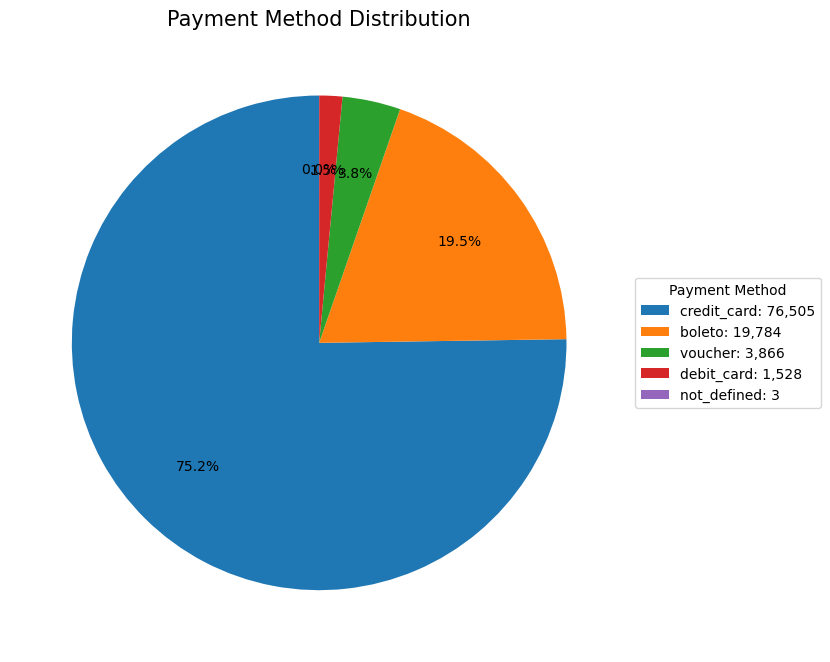

In [145]:
plt.figure(figsize=(8, 7))

data = payment_method_summary['order_count']

wedges, texts, autotexts = plt.pie(
    data,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.7
)

plt.title('Payment Method Distribution', fontsize=15)

plt.legend(
    wedges,
    [f'{method}: {count:,}' 
     for method, count in zip(data.index, data)],
    title='Payment Method',
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.show()

In [146]:
#Review Score Distribution

In [147]:
review_summary = (
    reviews['review_score']
    .value_counts()
    .sort_index()
    .to_frame('review_count')
)

review_summary['percentage'] = (
    review_summary['review_count']
    / review_summary['review_count'].sum() * 100
).round(2)

review_summary

,review_count,percentage
review_score,,
1,11424,11.51
2,3151,3.18
3,8179,8.24
4,19142,19.29
5,57328,57.78


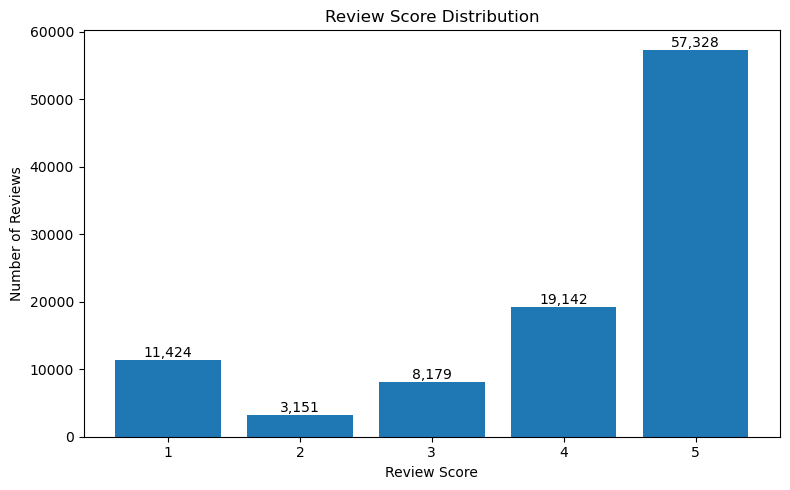

In [148]:
plt.figure(figsize=(8, 5))

data = review_summary['review_count']

bars = plt.bar(data.index.astype(str), data.values)

plt.title('Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')

for bar, value in zip(bars, data.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{value:,}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [149]:
#Monthly Revenue Trend

In [150]:
sales_with_date = sales_analysis.merge(
    orders[['order_id', 'order_purchase_timestamp']],
    on='order_id',
    how='left'
)

print("Sales + Date dataset created!")
print("Rows:", len(sales_with_date))

Sales + Date dataset created!
Rows: 112650


In [151]:
sales_with_date['purchase_year'] = (
    sales_with_date['order_purchase_timestamp'].dt.year
)

sales_with_date['purchase_month'] = (
    sales_with_date['order_purchase_timestamp'].dt.month
)

In [152]:
monthly_revenue = (
    sales_with_date
    .groupby(['purchase_year', 'purchase_month'])['item_revenue']
    .sum()
    .reset_index()
)

monthly_revenue

,purchase_year,purchase_month,item_revenue
0,2016,9,267.36
1,2016,10,49507.66
2,2016,12,10.90
3,2017,1,120312.87
4,2017,2,247303.02
5,2017,3,374344.30
6,2017,4,359927.23
7,2017,5,506071.14
8,2017,6,433038.60
9,2017,7,498031.48


In [153]:
monthly_revenue['month_name'] = pd.to_datetime(
    monthly_revenue['purchase_month'],
    format='%m'
).dt.strftime('%b')

monthly_revenue['month_year'] = (
    monthly_revenue['month_name']
    + ' '
    + monthly_revenue['purchase_year'].astype(str)
)

monthly_revenue.head()

,purchase_year,purchase_month,item_revenue,month_name,month_year
0,2016,9,267.36,Sep,Sep 2016
1,2016,10,49507.66,Oct,Oct 2016
2,2016,12,10.90,Dec,Dec 2016
3,2017,1,120312.87,Jan,Jan 2017
4,2017,2,247303.02,Feb,Feb 2017


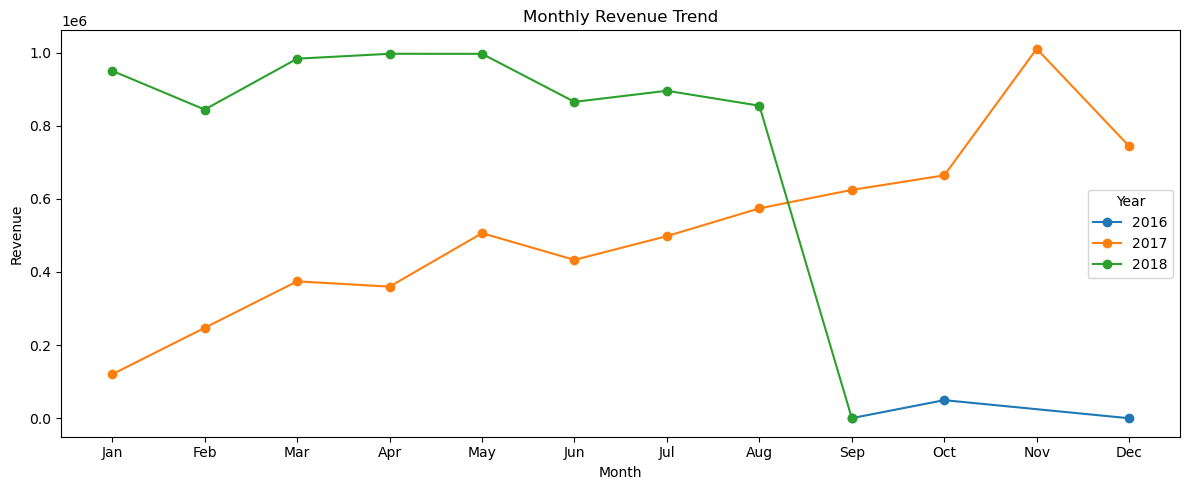

In [154]:
plt.figure(figsize=(12, 5))

for year in sorted(monthly_revenue['purchase_year'].unique()):
    
    data = monthly_revenue[
        monthly_revenue['purchase_year'] == year
    ]
    
    plt.plot(
        data['purchase_month'],
        data['item_revenue'],
        marker='o',
        label=str(year)
    )

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(
    range(1, 13),
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
)

plt.legend(title='Year')
plt.tight_layout()
plt.show()

In [155]:
#Top 10 Product Categories by Number of Orders

In [156]:
top_categories_orders = (
    sales_analysis
    .groupby('product_category_name_english')['order_id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

top_categories_orders

product_category_name_english
bed_bath_table           9417
health_beauty            8836
sports_leisure           7720
computers_accessories    6689
furniture_decor          6449
housewares               5884
watches_gifts            5624
telephony                4199
auto                     3897
toys                     3886
Name: order_id, dtype: int64

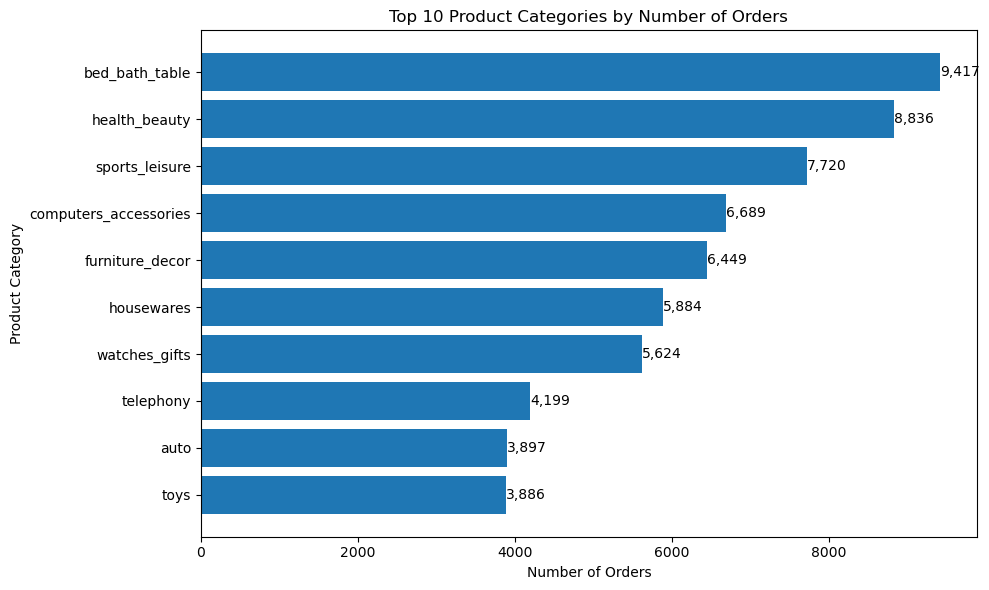

In [157]:
plt.figure(figsize=(10, 6))

data = top_categories_orders.sort_values()

bars = plt.barh(data.index, data.values)

plt.title('Top 10 Product Categories by Number of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('Product Category')

for bar, value in zip(bars, data.values):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f'{value:,}',
        va='center',
        ha='left'
    )

plt.tight_layout()
plt.show()

In [158]:
#Revenue by Product Category

In [159]:
revenue_by_category = (
    sales_analysis
    .groupby('product_category_name_english')['item_revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

revenue_by_category

product_category_name_english
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
furniture_decor           729762.49
cool_stuff                635290.85
housewares                632248.66
auto                      592720.11
garden_tools              485256.46
Name: item_revenue, dtype: float64

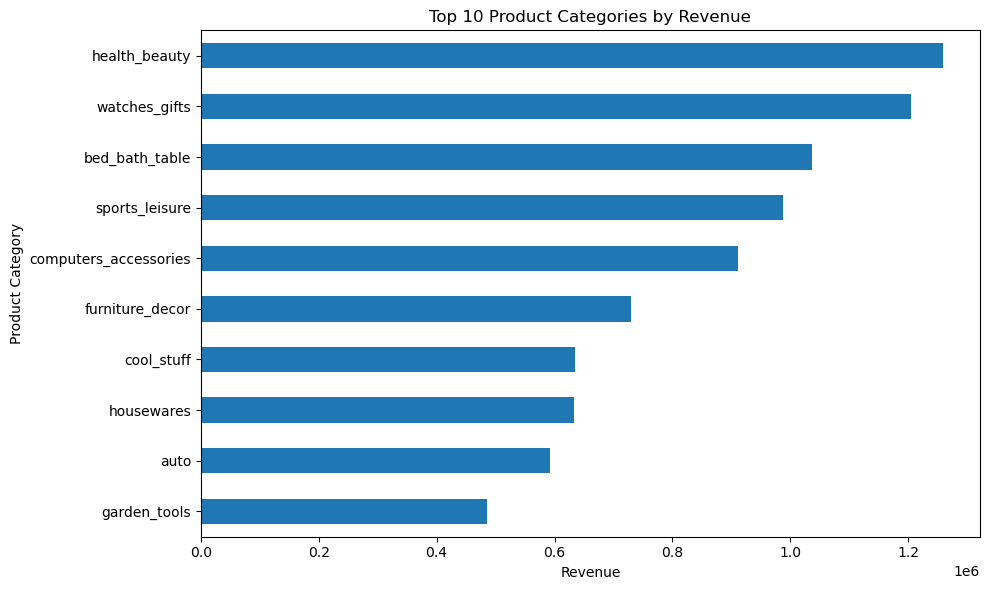

In [160]:
plt.figure(figsize=(10, 6))

revenue_by_category.sort_values().plot(kind='barh')

plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

In [161]:
#Revenue by City

In [162]:
city_revenue = sales_analysis.merge(
    orders_customer[['order_id', 'customer_city']],
    on='order_id',
    how='left'
)

revenue_by_city = (
    city_revenue
    .groupby('customer_city')['item_revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

revenue_by_city

customer_city
sao paulo         1914924.54
rio de janeiro     992538.86
belo horizonte     355611.13
brasilia           301920.25
curitiba           211738.06
porto alegre       190562.08
campinas           187844.53
salvador           181104.42
guarulhos          144268.39
niteroi            117907.12
Name: item_revenue, dtype: float64

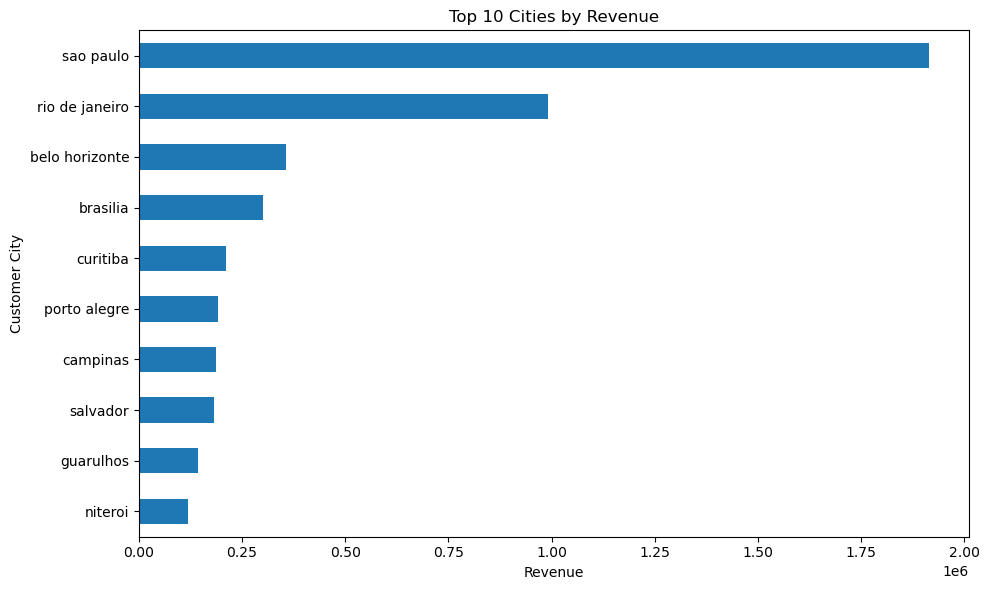

In [163]:
plt.figure(figsize=(10, 6))

revenue_by_city.sort_values().plot(kind='barh')

plt.title('Top 10 Cities by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Customer City')
plt.tight_layout()
plt.show()

In [164]:
#Shipping Days vs Review Score 


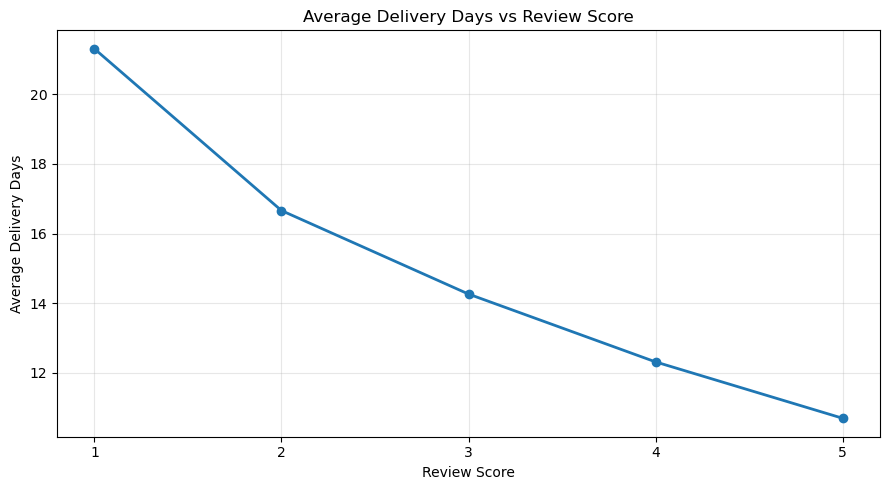

In [165]:
plt.figure(figsize=(9, 5))

plt.plot(
    avg_delivery_by_review.index,
    avg_delivery_by_review.values,
    marker='o',
    linewidth=2
)

plt.title('Average Delivery Days vs Review Score')
plt.xlabel('Review Score')
plt.ylabel('Average Delivery Days')
plt.xticks([1, 2, 3, 4, 5])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [166]:
review_delivery = reviews[['order_id', 'review_score']].merge(
    orders[['order_id', 'delivery_days']],
    on='order_id',
    how='left'
)

shipping_review = (
    review_delivery
    .groupby('review_score')['delivery_days']
    .mean()
    .round(2)
)

shipping_review

review_score
1    21.31
2    16.66
3    14.26
4    12.31
5    10.69
Name: delivery_days, dtype: float64

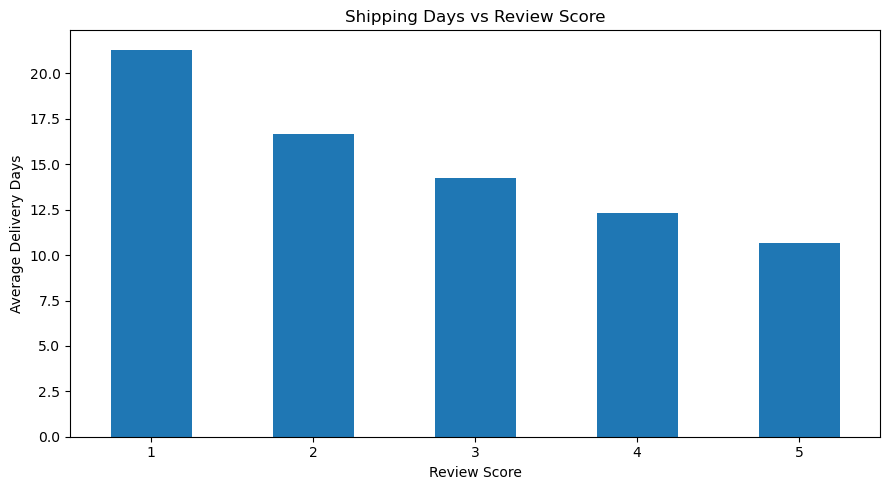

In [167]:
plt.figure(figsize=(9, 5))

shipping_review.plot(kind='bar')

plt.title('Shipping Days vs Review Score')
plt.xlabel('Review Score')
plt.ylabel('Average Delivery Days')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [168]:
#Order Value Analysis

In [169]:
total_revenue = payments['payment_value'].sum()
total_orders = payments['order_id'].nunique()

average_order_value = total_revenue / total_orders

print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Average Order Value: {average_order_value:,.2f}")

Total Revenue: 16,008,872.12
Total Orders: 99,440
Average Order Value: 160.99


In [170]:
aov_by_payment = (
    payments.groupby('payment_type')
    .agg(
        total_payment=('payment_value', 'sum'),
        number_of_orders=('order_id', 'nunique')
    )
)

aov_by_payment['average_order_value'] = (
    aov_by_payment['total_payment'] /
    aov_by_payment['number_of_orders']
)

aov_by_payment = aov_by_payment.sort_values(
    'average_order_value',
    ascending=False
).round(2)

aov_by_payment

,total_payment,number_of_orders,average_order_value
payment_type,,,
credit_card,12542084.19,76505,163.94
boleto,2869361.27,19784,145.03
debit_card,217989.79,1528,142.66
voucher,379436.87,3866,98.15
not_defined,0.00,3,0.00


In [171]:
#Monthly Average Order Value


In [172]:
orders_with_payment = orders[['order_id', 'order_purchase_timestamp']].merge(
    payments_by_order[['order_id', 'total_payment']],
    on='order_id',
    how='inner'
)

orders_with_payment['purchase_year'] = (
    orders_with_payment['order_purchase_timestamp'].dt.year
)

orders_with_payment['purchase_month'] = (
    orders_with_payment['order_purchase_timestamp'].dt.month
)

monthly_aov = (
    orders_with_payment
    .groupby(['purchase_year', 'purchase_month'])
    .agg(
        total_revenue=('total_payment', 'sum'),
        number_of_orders=('order_id', 'nunique')
    )
)

monthly_aov['average_order_value'] = (
    monthly_aov['total_revenue'] /
    monthly_aov['number_of_orders']
)

monthly_aov = monthly_aov.reset_index()

monthly_aov

,purchase_year,purchase_month,total_revenue,number_of_orders,average_order_value
0,2016,9,252.24,3,84.080000
1,2016,10,59090.48,324,182.378025
2,2016,12,19.62,1,19.620000
3,2017,1,138488.04,800,173.110050
4,2017,2,291908.01,1780,163.993264
5,2017,3,449863.60,2682,167.734377
6,2017,4,417788.03,2404,173.788698
7,2017,5,592918.82,3700,160.248330
8,2017,6,511276.38,3245,157.558206
9,2017,7,592382.92,4026,147.139324


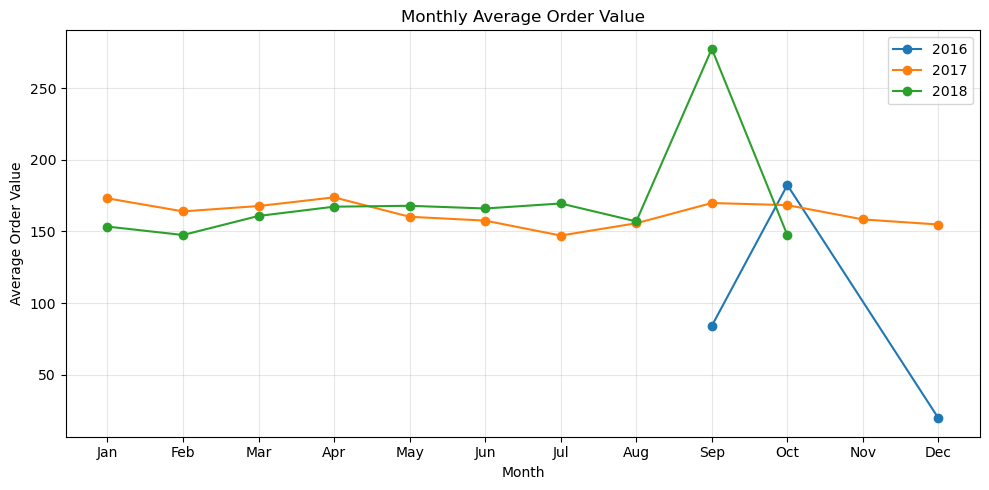

In [173]:
month_names = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]

plt.figure(figsize=(10, 5))

for year in sorted(monthly_aov['purchase_year'].unique()):
    year_data = monthly_aov[
        monthly_aov['purchase_year'] == year
    ]

    plt.plot(
        year_data['purchase_month'],
        year_data['average_order_value'],
        marker='o',
        label=str(year)
    )

plt.title('Monthly Average Order Value')
plt.xlabel('Month')
plt.ylabel('Average Order Value')
plt.xticks(range(1, 13), month_names)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [174]:
#Revenue by Payment Type

In [175]:
revenue_by_payment = (
    payments
    .groupby('payment_type')['payment_value']
    .sum()
    .sort_values(ascending=False)
)

revenue_by_payment

payment_type
credit_card    12542084.19
boleto          2869361.27
voucher          379436.87
debit_card       217989.79
not_defined           0.00
Name: payment_value, dtype: float64

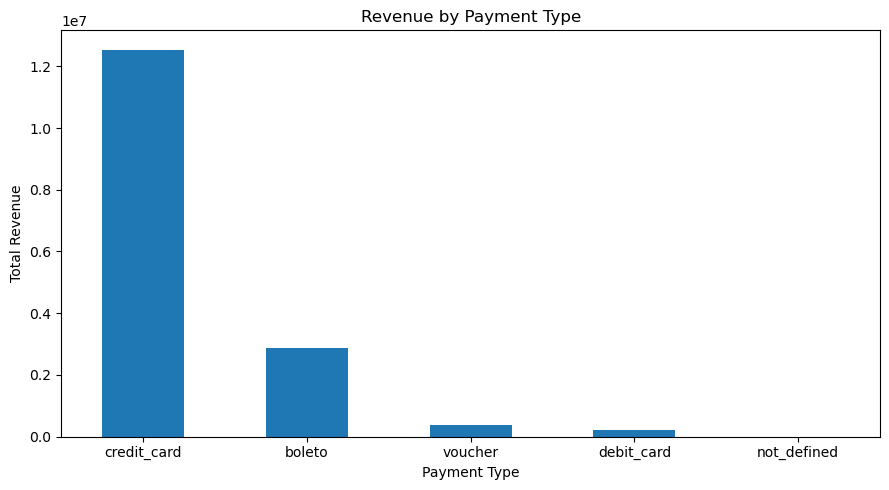

In [176]:
plt.figure(figsize=(9, 5))

revenue_by_payment.plot(kind='bar')

plt.title('Revenue by Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [177]:
#Top 10 Sellers by Revenue


In [178]:
top_sellers = (
    order_items
    .groupby('seller_id')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_sellers


seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    229472.63
53243585a1d6dc2643021fd1853d8905    222776.05
4a3ca9315b744ce9f8e9374361493884    200472.92
fa1c13f2614d7b5c4749cbc52fecda94    194042.03
7c67e1448b00f6e969d365cea6b010ab    187923.89
7e93a43ef30c4f03f38b393420bc753a    176431.87
da8622b14eb17ae2831f4ac5b9dab84a    160236.57
7a67c85e85bb2ce8582c35f2203ad736    141745.53
1025f0e2d44d7041d6cf58b6550e0bfa    138968.55
955fee9216a65b617aa5c0531780ce60    135171.70
Name: price, dtype: float64

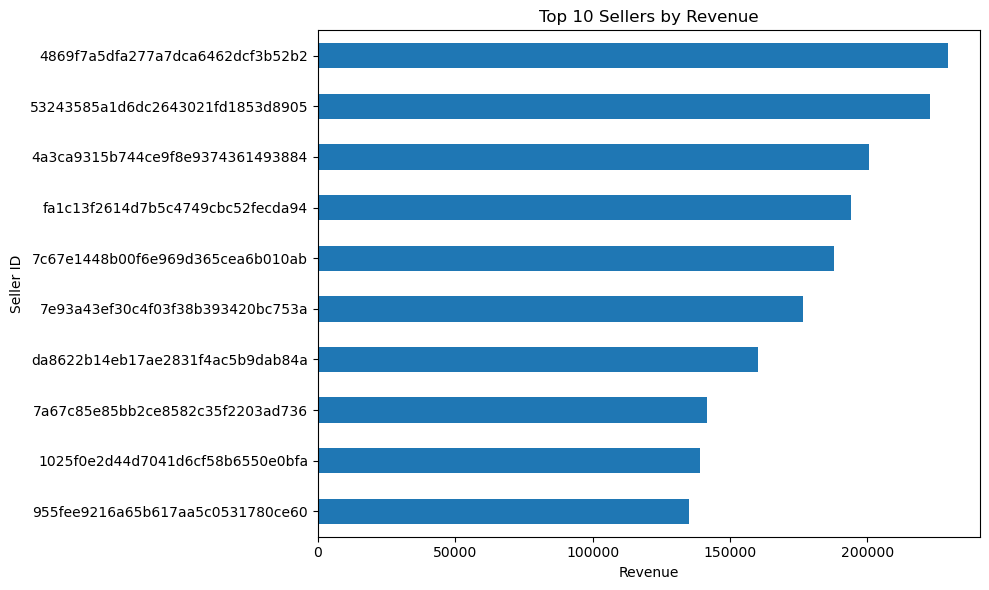

In [179]:
plt.figure(figsize=(10, 6))

top_sellers.sort_values().plot(kind='barh')

plt.title('Top 10 Sellers by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Seller ID')
plt.tight_layout()
plt.show()


In [180]:
#Top 10 Product Categories by Number of Products


In [181]:
products_with_category = products.merge(
    category_translation,
    on='product_category_name',
    how='left'
)

top_categories_products = (
    products_with_category
    .groupby('product_category_name_english')['product_id']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

top_categories_products

product_category_name_english
bed_bath_table           3029
sports_leisure           2867
furniture_decor          2657
health_beauty            2444
housewares               2335
auto                     1900
computers_accessories    1639
toys                     1411
watches_gifts            1329
telephony                1134
Name: product_id, dtype: int64

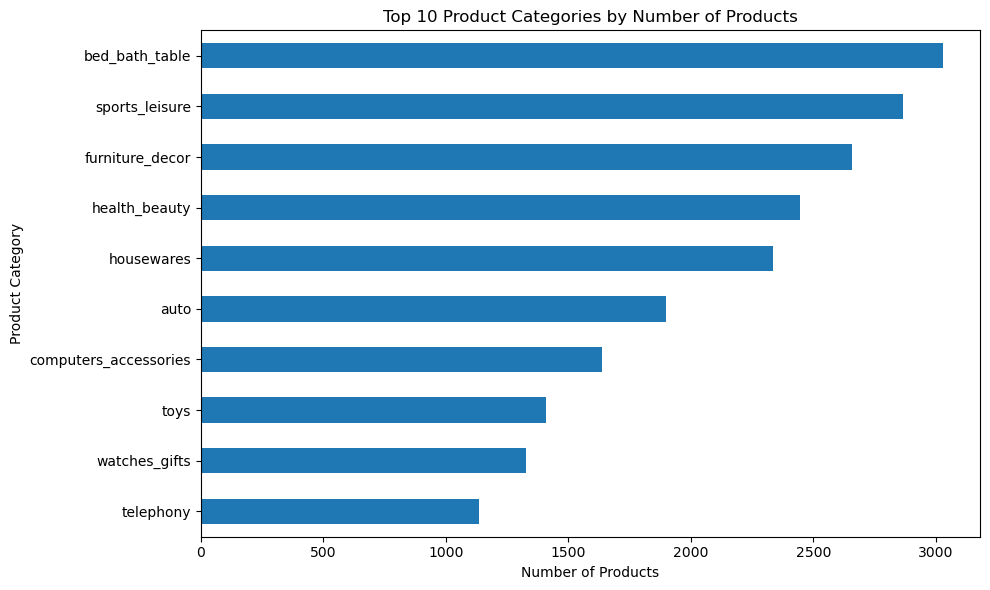

In [182]:
plt.figure(figsize=(10, 6))

top_categories_products.sort_values().plot(kind='barh')

plt.title('Top 10 Product Categories by Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

In [183]:
#Delivery Performance: On-Time vs Late Delivery


In [184]:
delivery_analysis = orders[
    orders['order_status'] == 'delivered'
].copy()

delivery_analysis['delivery_performance'] = np.where(
    delivery_analysis['order_delivered_customer_date']
    <= delivery_analysis['order_estimated_delivery_date'],
    'On Time',
    'Late'
)

delivery_performance = (
    delivery_analysis['delivery_performance']
    .value_counts()
)

delivery_performance

delivery_performance
On Time    88644
Late        7834
Name: count, dtype: int64

In [185]:
delivery_percentage = (
    delivery_performance /
    delivery_performance.sum() * 100
).round(2)

delivery_summary = pd.DataFrame({
    'Orders': delivery_performance,
    'Percentage': delivery_percentage
})

delivery_summary

,Orders,Percentage
delivery_performance,,
On Time,88644,91.88
Late,7834,8.12


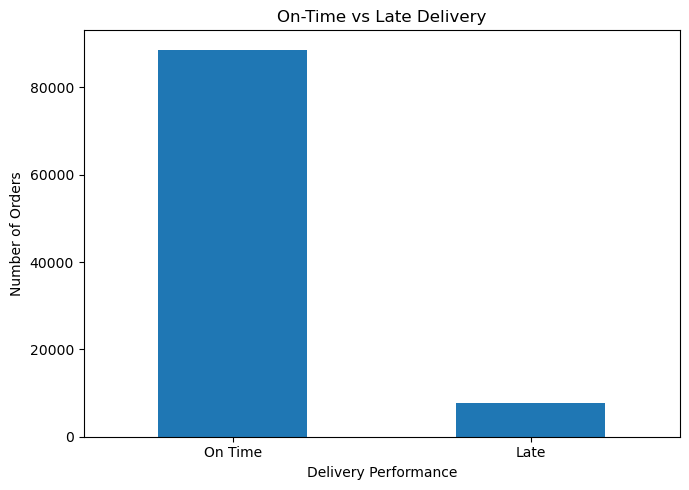

In [186]:
plt.figure(figsize=(7, 5))

delivery_performance.plot(kind='bar')

plt.title('On-Time vs Late Delivery')
plt.xlabel('Delivery Performance')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [187]:
#Freight Cost Analysis


In [188]:
freight_summary = order_items.agg(
    total_freight=('freight_value', 'sum'),
    average_freight=('freight_value', 'mean'),
    minimum_freight=('freight_value', 'min'),
    maximum_freight=('freight_value', 'max')
).round(2)

freight_summary

,freight_value
total_freight,2251909.54
average_freight,19.99
minimum_freight,0.00
maximum_freight,409.68


In [189]:
freight_by_category = (
    sales_analysis
    .groupby('product_category_name_english')['freight_value']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

freight_by_category

product_category_name_english
bed_bath_table           204693.04
health_beauty            182566.73
furniture_decor          172749.30
sports_leisure           168607.51
computers_accessories    147318.08
housewares               146149.11
watches_gifts            100535.93
garden_tools              98962.75
auto                      92664.21
cool_stuff                84039.10
Name: freight_value, dtype: float64

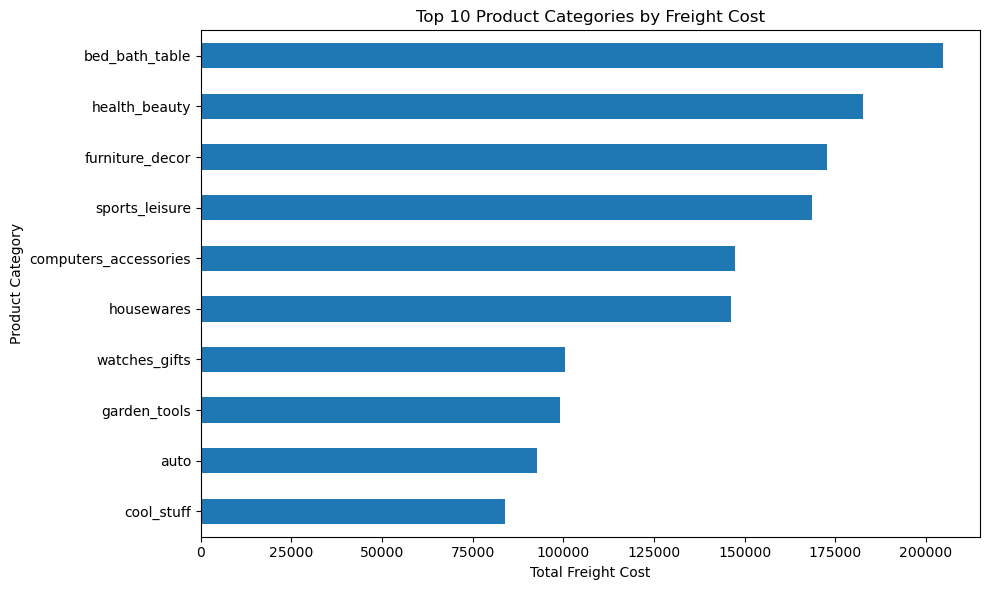

In [190]:
plt.figure(figsize=(10, 6))

freight_by_category.sort_values().plot(kind='barh')

plt.title('Top 10 Product Categories by Freight Cost')
plt.xlabel('Total Freight Cost')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

## 3️⃣ Key Performance Indicators (KPIs)

The following KPIs summarize the overall performance of the Olist e-commerce platform:

| KPI | Description |
|---|---|
| Total Revenue | Total payment value generated from orders |
| Total Orders | Number of unique orders |
| Average Order Value (AOV) | Average revenue generated per order |
| Average Delivery Time | Average number of days taken to deliver orders |
| Average Review Score | Average customer rating |
| 5-Star Credit Card Orders | Number of orders with a 5-star review and credit-card payment |
| Pet Shop Average Delivery Time | Average delivery time for pet shop orders |
| Weekday vs Weekend Payments | Comparison of payment value and orders by day type |

In [191]:
kpi_summary = pd.DataFrame({
    'KPI': [
        'Total Revenue',
        'Total Orders',
        'Average Order Value (AOV)',
        'Average Delivery Time',
        'Average Review Score'
    ],
    'Value': [
        payments['payment_value'].sum(),
        payments['order_id'].nunique(),
        payments['payment_value'].sum() / payments['order_id'].nunique(),
        orders['delivery_days'].mean(),
        reviews['review_score'].mean()
    ]
})

kpi_summary

,KPI,Value
0,Total Revenue,1.600887e+07
1,Total Orders,9.944000e+04
2,Average Order Value (AOV),1.609903e+02
3,Average Delivery Time,1.255822e+01
4,Average Review Score,4.086421e+00


## 4️⃣ Key Business Insights

### 📊 Sales & Revenue
- The analysis identifies the highest-revenue product categories and the categories generating the most orders.
- Monthly revenue and order trends help identify changes in sales performance over time.
- Average Order Value (AOV) provides an indication of customer spending per order.

### 💳 Payment Analysis
- Credit card is the most widely used payment method.
- Payment analysis helps understand customer payment preferences and their contribution to order volume and revenue.
- Weekday and weekend payment analysis provides insight into customer purchasing behavior.

### 🚚 Delivery Performance
- Delivery time has a clear relationship with customer satisfaction.
- Orders with lower review scores generally have longer average delivery times.
- On-time versus late delivery analysis helps evaluate logistics performance.

### ⭐ Customer Satisfaction
- 5-star reviews represent the largest share of customer ratings.
- Faster delivery is associated with better customer review scores.

### 🛍️ Product & Seller Performance
- A small number of product categories contribute significantly to overall revenue.
- Top-category and seller analysis helps identify important contributors to e-commerce performance.

## 5️⃣ Conclusion

The Olist E-Commerce Analytics project provides an end-to-end analysis of e-commerce performance using Python.

The analysis covered sales, revenue, payments, products, sellers, customers, delivery performance, and customer reviews. The findings highlight the importance of monitoring revenue trends, customer spending, payment behavior, delivery efficiency, and customer satisfaction.

The relationship between delivery time and review scores indicates that improving delivery performance can contribute to a better customer experience.

Overall, this project demonstrates how Python and data analytics techniques can transform raw e-commerce data into meaningful business insights and support data-driven decision-making.
